In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [51]:
train_data=pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv') 
test_data=pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')
sub=pd.read_csv('/kaggle/input/competitions/spaceship-titanic/sample_submission.csv')

In [52]:
train_data.head(3)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


In [53]:
train_data.shape
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [54]:
train_data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [55]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


Подготовка данных, работа с признаками

Разделяем колонки Cabin и PassengerId для лучшей информативности

In [56]:
train_data[['deck','Cabin_num','side']]=train_data['Cabin'].str.split('/',expand=True)
test_data[['deck','Cabin_num','side']]=test_data['Cabin'].str.split('/',expand=True)
train_data[['Group_num','Member_num']]=train_data['PassengerId'].str.split('_',expand=True)
test_data[['Group_num','Member_num']]=test_data['PassengerId'].str.split('_',expand=True)

Удаляем колонки Cabin и PassengerId

In [57]:
train_data=train_data.drop('Cabin',axis=1)
test_data=test_data.drop('Cabin',axis=1)
train_data=train_data.drop('PassengerId',axis=1)

Заполняем колонки с тратами

In [58]:
def filling_spending_col(df):
    spending_columns=['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
    for col in spending_columns:
        df[col].fillna(0,inplace=True)
filling_spending_col(train_data)
filling_spending_col(test_data)

Создадим одну колонку с суммарными тратами

In [59]:
cols=['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
train_data['Totalspend']=train_data[cols].sum(axis=1)
test_data['Totalspend']=test_data[cols].sum(axis=1)
# train_data.drop(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck'],axis=1,inplace=True)
# test_data.drop(['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck'],axis=1,inplace=True)

Удаляем Колонку Name

In [60]:
train_data.drop('Name',axis=1,inplace=True)
test_data.drop('Name',axis=1,inplace=True)

In [61]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Destination   8511 non-null   object 
 3   Age           8514 non-null   float64
 4   VIP           8490 non-null   object 
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  deck          8494 non-null   object 
 12  Cabin_num     8494 non-null   object 
 13  side          8494 non-null   object 
 14  Group_num     8693 non-null   object 
 15  Member_num    8693 non-null   object 
 16  Totalspend    8693 non-null   float64
dtypes: bool(1), float64(7), object(9)
memory usage: 1.1+ MB


Заполняем категориальные признаки

In [62]:
categorical_cols=['HomePlanet','Destination','deck','side']
for cols in categorical_cols:
    train_data[cols].fillna(train_data[cols].mode()[0],inplace=True)
    test_data[cols].fillna(test_data[cols].mode()[0],inplace=True)

Колонки CryoSleep и VIP заполним 'False'

In [63]:
train_data['CryoSleep'].fillna(False,inplace=True)
test_data['CryoSleep'].fillna(False,inplace=True)
train_data['VIP'].fillna(False,inplace=True)
test_data['VIP'].fillna(False,inplace=True)

In [64]:
numeric_cols=['Cabin_num','Group_num','Member_num']
for col in numeric_cols:
    train_data[col]=pd.to_numeric(train_data[col],errors='coerce')
    test_data[col]=pd.to_numeric(test_data[col],errors='coerce')

In [65]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   object 
 1   CryoSleep     8693 non-null   bool   
 2   Destination   8693 non-null   object 
 3   Age           8514 non-null   float64
 4   VIP           8693 non-null   bool   
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  deck          8693 non-null   object 
 12  Cabin_num     8494 non-null   float64
 13  side          8693 non-null   object 
 14  Group_num     8693 non-null   int64  
 15  Member_num    8693 non-null   int64  
 16  Totalspend    8693 non-null   float64
dtypes: bool(3), float64(8), int64(2), object(4)
memory usage: 976.4+ KB


In [66]:
train_data['Age'].fillna(train_data['Age'].mode()[0],inplace=True)
test_data['Age'].fillna(test_data['Age'].mode()[0],inplace=True)
train_data['Cabin_num'].fillna(0,inplace=True)
test_data['Cabin_num'].fillna(0,inplace=True)


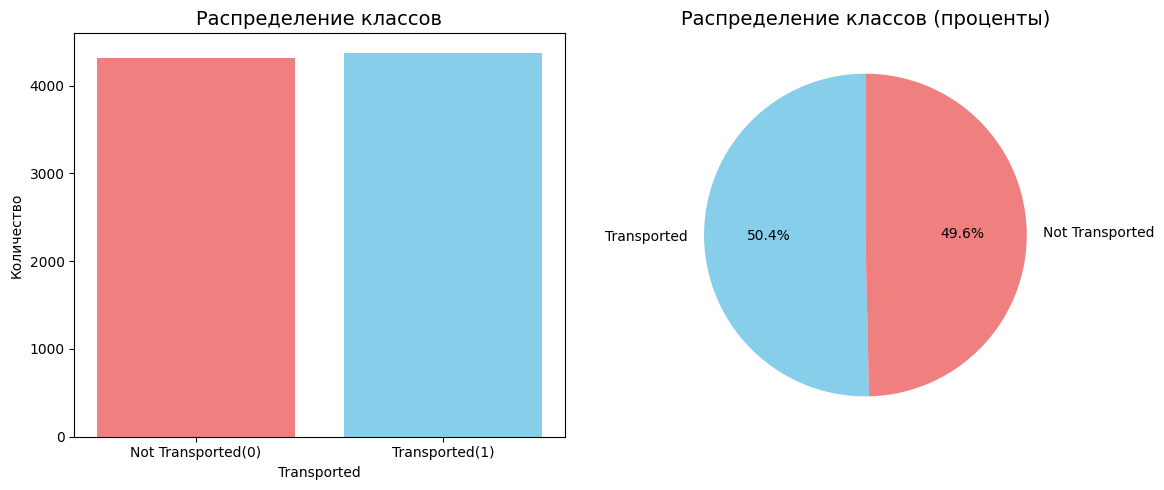

Transported
True     4378
False    4315
Name: count, dtype: int64


In [67]:
class_counts=train_data['Transported'].value_counts()
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].bar(class_counts.index,class_counts.values,color=['skyblue','lightcoral'])
axes[0].set_title('Распределение классов',fontsize=14)
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Количество')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Not Transported(0)','Transported(1)'])
axes[1].pie(class_counts.values, labels=['Transported', 'Not Transported'], 
            autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
axes[1].set_title('Распределение классов (проценты)', fontsize=14)
plt.tight_layout()
plt.show()
print(class_counts)

In [68]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   object 
 1   CryoSleep     8693 non-null   bool   
 2   Destination   8693 non-null   object 
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   bool   
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  deck          8693 non-null   object 
 12  Cabin_num     8693 non-null   float64
 13  side          8693 non-null   object 
 14  Group_num     8693 non-null   int64  
 15  Member_num    8693 non-null   int64  
 16  Totalspend    8693 non-null   float64
dtypes: bool(3), float64(8), int64(2), object(4)
memory usage: 976.4+ KB


In [97]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix ,roc_auc_score
scaler=StandardScaler()
train_data_encoded=train_data.copy()
test_data_encoded=test_data.copy()
target='Transported'
categorical_features=['HomePlanet','Destination','deck','side']
for col in categorical_features:
    le=LabelEncoder()
    train_data_encoded[col]=le.fit_transform(train_data_encoded[col])
    test_data_encoded[col]=le.transform(test_data_encoded[col])
train_data['CryoSleep']=train_data['CryoSleep'].astype(int)
test_data['CryoSleep']=test_data['CryoSleep'].astype(int)
train_data['VIP']=train_data['VIP'].astype(int)
test_data['VIP']=test_data['VIP'].astype(int)
train_data_encoded['CryoSleep']=train_data_encoded['CryoSleep'].astype(int)
test_data_encoded['CryoSleep']=test_data_encoded['CryoSleep'].astype(int)
train_data_encoded['VIP']=train_data_encoded['VIP'].astype(int)
test_data_encoded['VIP']=test_data_encoded['VIP'].astype(int)
X=train_data_encoded.drop(columns=[target])
y=train_data_encoded[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_train_scaled_df=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled_df=pd.DataFrame(X_test_scaled,columns=X_test.columns)
model=LogisticRegression(random_state=42)
model.fit(X_train_scaled_df,y_train)
y_pred=model.predict(X_test_scaled_df)
y_pred_proba=model.predict_proba(X_test_scaled_df)
print(f'Accuracy score: {accuracy_score(y_test,y_pred):.3f}')
print(f'Classification Report: {classification_report(y_test,y_pred)}')
print(f'Confusion Matrix: {confusion_matrix(y_test,y_pred)}')

Accuracy score: 0.783
Classification Report:               precision    recall  f1-score   support

       False       0.78      0.77      0.78      1295
        True       0.78      0.79      0.79      1313

    accuracy                           0.78      2608
   macro avg       0.78      0.78      0.78      2608
weighted avg       0.78      0.78      0.78      2608

Confusion Matrix: [[1003  292]
 [ 275 1038]]


Строим ConfusionMatrix 

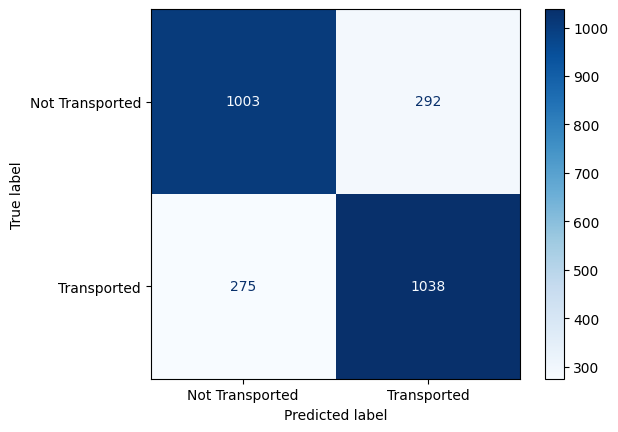

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model,X_test_scaled,y_test,display_labels=['Not Transported','Transported'],cmap='Blues')

Строим CorrelationMatrix

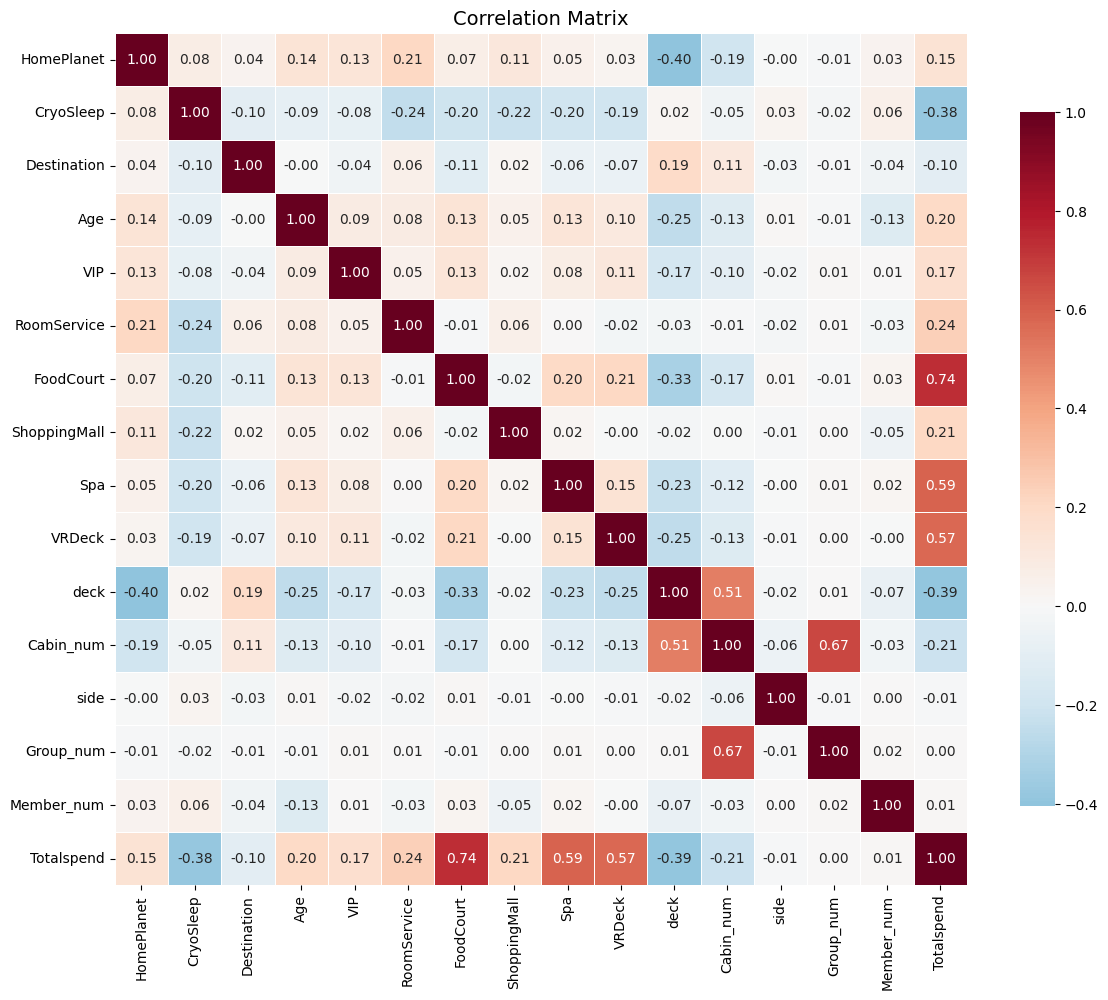

In [71]:
plt.figure(figsize=(12,10))
correlation_matrix=X_train_scaled_df.corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,linewidths=0.5,cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix',fontsize=14)
plt.tight_layout()
plt.show()

Обучить KNN и SVM и сравним значения метрик

In [72]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
knn_param_grid={'n_neighbors':range(3,21),
               'weights': ['uniform','distance'],
               'metric':['euclidian','manhattan','minkowski'],
               'p': [1,2]}
knn_grid=GridSearchCV(KNeighborsClassifier(),knn_param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
knn_grid.fit(X_train_scaled,y_train)
print(knn_grid.best_params_)
print(f'Лучший score на CV: {knn_grid.best_score_:.4f}')
y_pred_knn_grid=knn_grid.predict(X_test_scaled)
print(f'Точность на тесте: {accuracy_score(y_test,y_pred_knn_grid):.4f}')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'metric': 'manhattan', 'n_neighbors': 17, 'p': 1, 'weights': 'uniform'}
Лучший score на CV: 0.7975
Точность на тесте: 0.7807


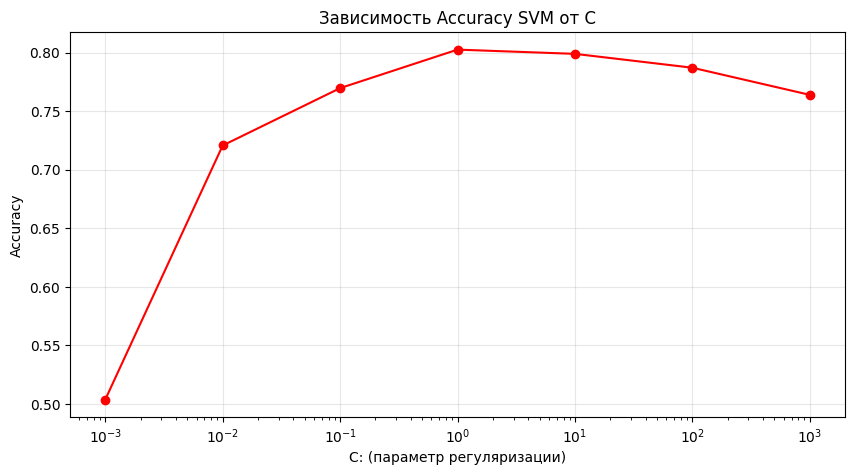

In [73]:
C_range=[0.001,0.01,0.1,1,10,100,1000]
svm_scores=[]
for C in C_range:
    svm=SVC(kernel='rbf',C=C,random_state=42)
    scores=cross_val_score(svm,X_train_scaled,y_train,cv=5,scoring='accuracy')
    svm_scores.append(scores.mean())
plt.figure(figsize=(10,5))
plt.semilogx(C_range,svm_scores,'ro-',markersize=6)
plt.xlabel('C: (параметр регуляризации)')
plt.ylabel('Accuracy')
plt.title('Зависимость Accuracy SVM от C')
plt.grid(True,alpha=0.3)
plt.show()


In [74]:
svm_best_C=SVC(kernel='rbf',C=10,random_state=42)
svm_best_C.fit(X_train_scaled,y_train)
svm_pred=svm_best_C.predict(X_test_scaled)
print(f'Точноcть на тесте: {accuracy_score(y_test,svm_pred):.4f}')

Точноcть на тесте: 0.7811


Теперь обучим RandomForest,XGBoost,LightGBM,CatBoost и Мета Модель: Линейную регрессию 

In [75]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
y_pred_rf_proba=rf.predict_proba(X_test)[:,1]
print (f'Accuracy: {accuracy_score(y_test,y_pred_rf):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test,y_pred_rf_proba):.4f}')

Accuracy: 0.7995
ROC-AUC: 0.8936


In [76]:
rf_param_grid={'n_estimators':[100,200,300],
              'max_depth': [10,15,15],
              'min_samples_split': [2,5,10],
              'min_samples_leaf':[1,2,4]}
rf_grid=GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),rf_param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
rf_grid.fit(X_train,y_train)
print (f'Лучшие Параметры: {rf_grid.best_params_}')
best_rf=rf_grid.best_estimator_
y_pred_best=best_rf.predict(X_test)
print(f'Точность на тесте: {accuracy_score(y_test,y_pred_best):.4f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие Параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Точность на тесте: 0.7952


In [77]:
import xgboost as xgb
xgb_base=xgb.XGBClassifier(objective='binary:logistic',random_state=42,use_label_encoder=False,eval_metric='logloss')
xgb_base.fit(X_train,y_train)
y_pred_xgb_base=xgb_base.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test,y_pred_xgb_base):.4f}')

Accuracy: 0.8090


In [78]:
xgb_param_grid={'n_estimators':[100,200,300],
               'max_depth':[2,4,5,7],
               'learning_rate':[0.01,0.05,0.1]
               }
xgb_grid=GridSearchCV(xgb.XGBClassifier(objective='binary:logistic',
        random_state=42,
        eval_metric='logloss'),xgb_param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
xgb_grid.fit(X_train_scaled,y_train)
print (f'Лучшие параметры XGBoost: {xgb_grid.best_params_}')
best_xgb=xgb_grid.best_estimator_
y_pred_best_xgb=best_xgb.predict(X_test_scaled)
print(f'\nТочность на тесте: {accuracy_score(y_test,y_pred_best):.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

Точность на тесте: 0.7952


In [79]:
import lightgbm as lgb
from catboost import CatBoostClassifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_scaled,y_train)
lgb_pred=lgb_model.predict(X_test_scaled)
print(f'LGB Accuracy: {accuracy_score(y_test,lgb_pred):.4f}')

LGB Accuracy: 0.8106


In [80]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   object 
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   object 
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  deck          8693 non-null   object 
 12  Cabin_num     8693 non-null   float64
 13  side          8693 non-null   object 
 14  Group_num     8693 non-null   int64  
 15  Member_num    8693 non-null   int64  
 16  Totalspend    8693 non-null   float64
dtypes: bool(1), float64(8), int64(4), object(4)
memory usage: 1.1+ MB


CatBoost без подбора гиперпараметров

In [81]:
cat_model=CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=250,
    early_stopping_rounds=50
)
cat_model.fit(X_train_scaled,y_train)
cat_pred=cat_model.predict(X_test_scaled)
print(f'CatBoost Accuracy: {accuracy_score(y_test,cat_pred):.4f}')

0:	total: 56.5ms	remaining: 28.2s
250:	total: 742ms	remaining: 736ms
499:	total: 1.44s	remaining: 0us
CatBoost Accuracy: 0.8106


CatBoost с подбором гиперпараметров с помощью GridSearchCV

In [102]:
param_grid_cat={
    'l2_leaf_reg':[1,3,5,7]
}
catboost_base=CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50
)
grid_search_catboost=GridSearchCV(
    estimator=catboost_base,
    param_grid=param_grid_cat,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_catboost.fit(X_train_scaled,y_train)
print(f'Лучшие параметры CatBoost: {grid_search_catboost.best_params_}')
best_catboost=grid_search_catboost.best_estimator_
y_pred=best_catboost.predict(X_test_scaled)
print(f'CatBoost with GridSearchCV Accuracy: {accuracy_score(y_test,y_pred):.4f}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие параметры CatBoost: {'l2_leaf_reg': 7}
CatBoost with GridSearchCV Accuracy: 0.8129


In [98]:
train_meta_features=np.column_stack([
    rf.predict(X_train),
    xgb_base.predict(X_train),
    lgb_model.predict(X_train_scaled),
    best_catboost.predict(X_train_scaled)
])
test_meta_features=np.column_stack([
    y_pred_rf,
    y_pred_xgb_base,
    lgb_pred,
    y_pred
])
metamodel=LogisticRegressionCV(cv=5,random_state=42,max_iter=1000,)
metamodel.fit(train_meta_features,y_train)
y_pred_meta = metamodel.predict(test_meta_features)
y_pred_meta_proba=metamodel.predict_proba(test_meta_features)[:,1]
print(f'Accuracy Мета Модели: {accuracy_score(y_test,y_pred_meta):.4f}')

Accuracy Мета Модели: 0.8087


In [84]:
test_data.head(3)

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,deck,Cabin_num,side,Group_num,Member_num,Totalspend
0,0013_01,Earth,1,TRAPPIST-1e,27.0,0,0.0,0.0,0.0,0.0,0.0,G,3.0,S,13,1,0.0
1,0018_01,Earth,0,TRAPPIST-1e,19.0,0,0.0,9.0,0.0,2823.0,0.0,F,4.0,S,18,1,2832.0
2,0019_01,Europa,1,55 Cancri e,31.0,0,0.0,0.0,0.0,0.0,0.0,C,0.0,S,19,1,0.0


In [91]:
from IPython.display import FileLink
test_passenger_ids=test_data['PassengerId'].copy()
model=best_catboost
model.fit(
    train_data_encoded.drop(["Transported"], axis=1),
    train_data_encoded["Transported"]
)
X_test = test_data_encoded.drop(['PassengerId'], axis=1)
predictions_prob = model.predict_proba(X_test)[:, 1]
predictions_bool = (predictions_prob > 0.5).astype(bool)

output = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': predictions_bool
})
filename = 'submission.csv'
output.to_csv(filename, index=False)
print(f"Сабмишн сохранен как '{filename}'")
print(output.head())
FileLink('submission.csv')

Сабмишн сохранен как 'submission.csv'
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False


/kaggle/working/submission.csv

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,deck,Cabin_num,side,Group_num,Member_num,Totalspend
0,0013_01,0,1,2,27.0,0,0.0,0.0,0.0,0.0,0.0,6,3.0,1,13,1,0.0
1,0018_01,0,0,2,19.0,0,0.0,9.0,0.0,2823.0,0.0,5,4.0,1,18,1,2832.0
2,0019_01,1,1,0,31.0,0,0.0,0.0,0.0,0.0,0.0,2,0.0,1,19,1,0.0
3,0021_01,1,0,2,38.0,0,0.0,6652.0,0.0,181.0,585.0,2,1.0,1,21,1,7418.0
4,0023_01,0,0,2,20.0,0,10.0,0.0,635.0,0.0,0.0,5,5.0,1,23,1,645.0
